In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("xy_data.csv")
x = df["x"].values
y = df["y"].values

theta_values = np.arange(0, 51, 0.2)
M_values = np.arange(-0.05, 0.051, 0.01)
X_values = np.arange(0, 101, 0.2)

best_theta = None
best_M = None
best_X = None
best_error = np.inf

for theta in theta_values:
    theta_rad = np.radians(theta)
    cos_theta = np.cos(theta_rad)
    sin_theta = np.sin(theta_rad)

    for X in X_values:
        t = (x - X) * cos_theta + (y - 42) * sin_theta

        if np.any(t <= 6) or np.any(t >= 60):
            continue

        for M in M_values:
            exp_term = np.exp(M * np.abs(t))
            sin_term = np.sin(0.3 * t)

            x_pred = (
                t * cos_theta
                - exp_term * sin_term * sin_theta
                + X
            )

            y_pred = (
                42
                + t * sin_theta
                + exp_term * sin_term * cos_theta
            )

            error = np.sum(np.abs(x - x_pred) + np.abs(y - y_pred))

            if error < best_error:
                best_error = error
                best_theta = theta
                best_M = M
                best_X = X

                print("New Best Solution")
                print(f"Theta : {best_theta}")
                print(f"M     : {best_M}")
                print(f"X     : {best_X}")
                print(f"Error : {best_error:.6f}")

print("\n====================================")
print("FINAL BEST PARAMETERS")
print("====================================")
print(f"Theta : {best_theta}")
print(f"M     : {best_M}")
print(f"X     : {best_X}")
print(f"Error : {best_error:.6f}")

--------------------------------
New Best Solution
Theta : 0.0
M     : -0.05
X     : 49.400000000000006
Error : 24436.198079
--------------------------------
New Best Solution
Theta : 0.2
M     : -0.05
X     : 49.400000000000006
Error : 24340.376156
--------------------------------
New Best Solution
Theta : 0.4
M     : -0.05
X     : 49.6
Error : 24247.024524
--------------------------------
New Best Solution
Theta : 0.6000000000000001
M     : -0.05
X     : 49.6
Error : 24148.597938
--------------------------------
New Best Solution
Theta : 0.8
M     : -0.05
X     : 49.6
Error : 24048.358598
--------------------------------
New Best Solution
Theta : 1.0
M     : -0.05
X     : 49.800000000000004
Error : 23953.667221
--------------------------------
New Best Solution
Theta : 1.2000000000000002
M     : -0.05
X     : 49.800000000000004
Error : 23850.887362
--------------------------------
New Best Solution
Theta : 1.4000000000000001
M     : -0.05
X     : 50.0
Error : 23755.700055
-----------

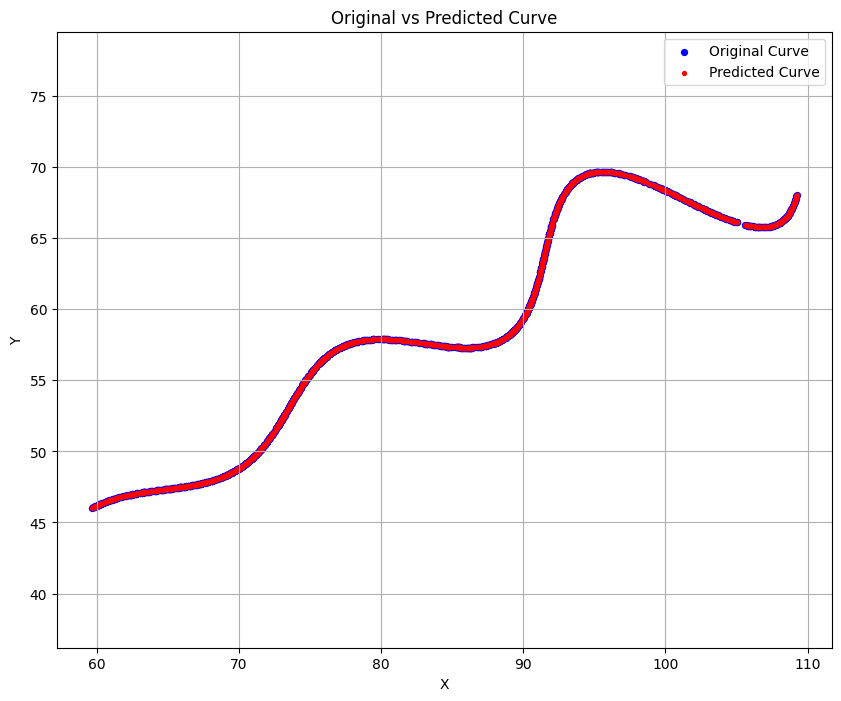

In [8]:
import matplotlib.pyplot as plt

# ==========================================================
# Generate Predicted Curve using Best Parameters
# ==========================================================

theta_rad = np.radians(best_theta)

cos_theta = np.cos(theta_rad)
sin_theta = np.sin(theta_rad)

# Compute t using derived equation
t = (x - best_X) * cos_theta + (y - 42) * sin_theta

exp_term = np.exp(best_M * np.abs(t))
sin_term = np.sin(0.3 * t)

x_pred = (
    t * cos_theta
    - exp_term * sin_term * sin_theta
    + best_X
)

y_pred = (
    42
    + t * sin_theta
    + exp_term * sin_term * cos_theta
)

# ==========================================================
# Plot Original and Predicted Curves
# ==========================================================

plt.figure(figsize=(10,8))

# Original Curve
plt.scatter(
    x,
    y,
    color='blue',
    s=18,
    label='Original Curve'
)

# Predicted Curve
plt.scatter(
    x_pred,
    y_pred,
    color='red',
    s=8,
    label='Predicted Curve'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Original vs Predicted Curve")
plt.legend()
plt.grid(True)

plt.axis("equal")     # Keeps X and Y scales identical

plt.show()